In [1]:
import hea
import polars as pl


### Replication of Ran et al. (2020)

### Figure 4d

In [2]:
d1 = pl.read_csv("https://raw.githubusercontent.com/berenslab/rgc_dendrites/refs/heads/master/data/processed/overlap.csv")

d1 = hea.tbl(d1).rename(
    roi_dist="dendritic_distance_between_rois", 
    angle="cbpt_angle_between_rois_deg",
    overlap="overlap_index", 
)
d1 = d1.select("cell_id", "type", "roi_dist", "overlap", "angle")
d1 = d1.with_columns(
    hea.factor(
        d1["type"].cast(pl.Int64), 
        labels={"0":"alpha transient", "1":"sustained", "2":"mini alpha", "3":"f-mini"}
    ), 
)

offsets = (
    d1.sort("type")
      .group_by("type", maintain_order=True)
      .agg((pl.col("cell_id").max() + 1).alias("step"))
      .with_columns(pl.col("step").cum_sum().shift(1, fill_value=0).alias("offset"))
      .select("type", "offset")
)
d1 = hea.tbl(
    d1.join(offsets, on="type")
      .with_columns(cell_id=pl.col("cell_id") + pl.col("offset"))
      .drop("offset")
)

d1 = d1.filter((pl.col("roi_dist") < 300))
d1 = d1.with_columns(hea.factor(d1["cell_id"].cast(pl.Int64)))

In [3]:
d1

cell_id,type,roi_dist,overlap,angle
enum,enum,f64,f64,f64
"""0""","""alpha transient""",11.655505,0.867386,132.988429
"""0""","""alpha transient""",3.325,0.97784,18.434949
"""0""","""alpha transient""",23.235176,0.918401,90.0
"""0""","""alpha transient""",30.507996,0.918557,65.149677
"""0""","""alpha transient""",9.281426,0.96853,81.869898
…,…,…,…,…
"""30""","""f-mini""",9.72642,0.911793,121.010898
"""30""","""f-mini""",3.274087,0.93578,7.958054
"""30""","""f-mini""",5.193016,0.999633,0.0


In [4]:
m1_d1 = hea.gam('overlap ~ type + te(roi_dist, angle, by=type, k=10)', data = d1)
m1_d1.summary()


Family: gaussian
Link function: identity

Formula: overlap ~ type + te(roi_dist, angle, by=type, k=10)

Parametric coefficients:
                 Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)     0.4651984   0.0008099  574.386   < 2e-16  ***
typesustained   0.3708086   0.0045604   81.310   < 2e-16  ***
typemini alpha  0.2563440   0.0053631   47.797   < 2e-16  ***
typef-mini      0.4499675   0.0725452    6.203  5.59e-10  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                          edf  Ref.df         F  p-value
te(roi_dist,angle):typealpha transient  91.47   96.73  1311.928   <2e-16  ***
te(roi_dist,angle):typesustained        60.06   72.20     8.236   <2e-16  ***
te(roi_dist,angle):typemini alpha       98.35   98.87    77.941   <2e-16  ***
te(roi_dist,angle):typef-mini           52.24   58.72     3.819   <2e-16  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq

In [5]:
m2_d1 = hea.gam('overlap ~ type + te(roi_dist, angle, by=type, k=20) + s(cell_id, bs="re")', data = d1)
m2_d1.summary()


Family: gaussian
Link function: identity

Formula: overlap ~ type + te(roi_dist, angle, by=type, k=20) + s(cell_id, bs="re")

Parametric coefficients:
                Estimate  Std. Error  t value  Pr(>|t|)
(Intercept)      0.52821     0.02583   20.447   < 2e-16  ***
typesustained    0.27978     0.05892    4.749  2.05e-06  ***
typemini alpha   0.22530     0.05409    4.165  3.11e-05  ***
typef-mini       0.28031     0.05444    5.149  2.62e-07  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                            edf   Ref.df        F  p-value
te(roi_dist,angle):typealpha transient  275.096  325.985  389.456  < 2e-16  ***
te(roi_dist,angle):typesustained         88.454  119.415    5.575  < 2e-16  ***
te(roi_dist,angle):typemini alpha       261.188  301.410   29.618  < 2e-16  ***
te(roi_dist,angle):typef-mini             4.412    5.462    3.444  0.00302  **
s(cell_id)                               26.5

In [6]:
hea.AIC(m1_d1, m2_d1)

               df        AIC
m1_d1  324.309517  -52105.46
m2_d1  734.703178  -59054.30


<Axes: title={'center': 'Normal Q-Q'}, xlabel='Theoretical Quantiles', ylabel='Std. deviance resid.'>

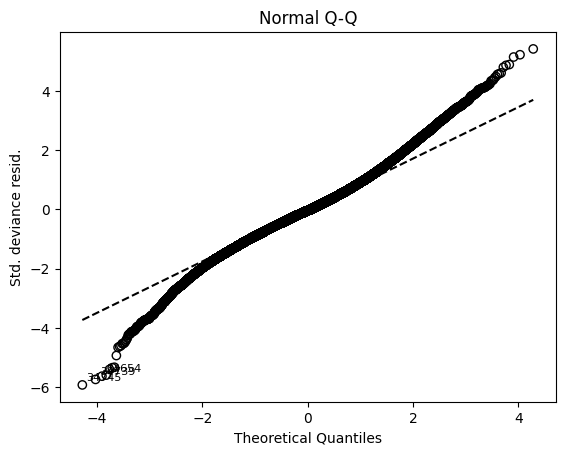

In [7]:
m2_d1.plot_qq()

In [8]:
from hea.family import scat
m3_d1 = hea.bam('overlap ~ type + te(roi_dist, angle, by=type, k=20) + s(cell_id, bs="re")', 
          data=d1, 
          family=scat(min_df=5), 
          discrete=True)
m3_d1.summary()


Family: scat
Link function: identity

Formula: overlap ~ type + te(roi_dist, angle, by=type, k=20) + s(cell_id, bs="re")

Parametric coefficients:
                Estimate  Std. Error  z value  Pr(>|z|)
(Intercept)      0.54760     0.02347   23.333   < 2e-16  ***
typesustained    0.26392     0.05198    5.077  3.84e-07  ***
typemini alpha   0.20728     0.04788    4.329  1.50e-05  ***
typef-mini       0.26483     0.05089    5.204  1.95e-07  ***
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                                           edf  Ref.df     Chi.sq   p-value
te(roi_dist,angle):typealpha transient  61.627  85.980  20513.136   < 2e-16  ***
te(roi_dist,angle):typef-mini            3.001   3.001      2.831     0.418
te(roi_dist,angle):typemini alpha       19.482  27.455   1203.038   < 2e-16  ***
te(roi_dist,angle):typesustained        10.094  13.833     70.724  1.43e-09  ***
s(cell_id)                              24.629  

<Axes: title={'center': 'Normal Q-Q'}, xlabel='Theoretical Quantiles', ylabel='Std. deviance resid.'>

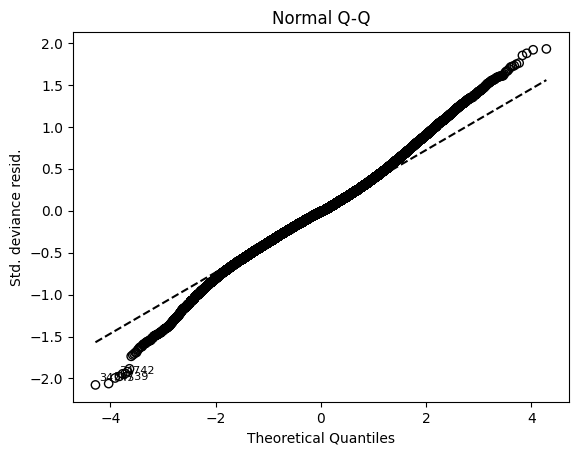

In [9]:
m3_d1.plot_qq()

In [10]:
hea.AIC(m3_d1)

               df     AIC
m3_d1  133.496539  5840.1


In [11]:
m3_d1.check()

Method: REML   Optimizer: outer newton
Smoothing parameters fixed by user — no outer optimization.
Model rank = 1631 / 1631

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

                                            k'    edf  k-index  p-value
te(roi_dist,angle):typealpha transient  399.00  61.63    0.984    0.060  .
te(roi_dist,angle):typef-mini           399.00   3.00    0.984    0.120
te(roi_dist,angle):typemini alpha       399.00  19.48    0.984    0.090  .
te(roi_dist,angle):typesustained        399.00  10.09    0.984    0.085  .
s(cell_id)                               31.00  24.63      NaN      NaN
---
Signif. codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


In [13]:
m1_d1.vis(view=["roi_dist", "angle"]).plot()

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 400 is different from 397)

ValueError: by='type' is not supported; expected a column name, `col == lit`, `col != lit`, or `as.numeric(...)` wrapping one of those

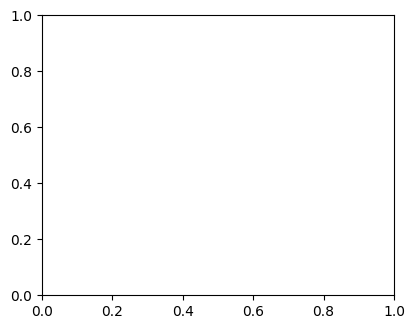

In [16]:
m1_d1.plot_smooth(n_cols=2)